In [1]:
# Import pandas
import pandas as pd

C:\Users\vanda\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Load the cleaned data
df = pd.read_csv("cleaned_customer_data_final.csv")

df.head()

,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,NaN,Ankit,Female,36.0,Mumbai,2024-12-31,2025-08-13,2460.355,2.0,NaN,NaN,Canada
1,C2,Ravi,Female,43.0,Kolkata,NaN,NaN,2460.355,3.0,NaN,NaN,Canada
2,3,Ravi,Female,66.0,Ahmedabad,NaN,2023-06-20,2460.355,3.0,user2@mail.com,NaN,India
3,C4,Ankit,Male,44.0,Kolkata,NaN,2025-09-13,2460.355,3.0,NaN,9.316268e+09,USA
4,5,Rahul,Male,43.0,Ahmedabad,2025-07-09,NaN,2460.355,3.0,NaN,9.234603e+09,USA


In [3]:
# Check the data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9983 entries, 0 to 9982
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   str    
 1   Name                9983 non-null   str    
 2   Gender              9983 non-null   str    
 3   Age                 9983 non-null   float64
 4   City                9983 non-null   str    
 5   Signup_Date         4996 non-null   str    
 6   Last_purchase_date  3348 non-null   str    
 7   purchase_amount     9983 non-null   float64
 8   feedback_score      9983 non-null   float64
 9   email               2512 non-null   str    
 10  Phone_number        2510 non-null   float64
 11  Country             9983 non-null   str    
dtypes: float64(4), str(8)
memory usage: 1.3 MB


In [4]:
# Check missing values
df.isnull().sum()

CustomerID            2362
Name                     0
Gender                   0
Age                      0
City                     0
Signup_Date           4987
Last_purchase_date    6635
purchase_amount          0
feedback_score           0
email                 7471
Phone_number          7473
Country                  0
dtype: int64

In [5]:
# Check numerical data
df.describe()

,Age,purchase_amount,feedback_score,Phone_number
count,9983.000000,9983.000000,9983.000000,2.510000e+03
mean,43.172393,2457.949213,2.990684,9.552822e+09
std,7.609630,717.007472,0.717035,2.595364e+08
min,18.000000,10.310000,1.000000,9.100236e+09
25%,43.000000,2460.355000,3.000000,9.330020e+09
50%,43.000000,2460.355000,3.000000,9.556068e+09
75%,43.000000,2460.355000,3.000000,9.778395e+09
max,70.000000,4998.670000,5.000000,9.999859e+09


In [6]:
# Average purchase amount by gender
df.groupby("Gender")["purchase_amount"].mean()

Gender
Female     2459.890718
Male       2463.845983
Unknown    2445.862894
Name: purchase_amount, dtype: float64

In [7]:
# Average purchase by country
df.groupby("Country")["purchase_amount"].mean().sort_values(ascending=False)

Country
Australia    2472.886995
UK           2468.007112
Canada       2457.081572
India        2456.672488
Unknown      2455.793778
USA          2437.553971
Name: purchase_amount, dtype: float64

In [8]:
# Average purchase by feedback score
df.groupby("feedback_score")["purchase_amount"].mean()

feedback_score
1.0    2445.871325
2.0    2436.067354
3.0    2462.957950
4.0    2453.379964
5.0    2417.825038
Name: purchase_amount, dtype: float64

In [9]:
# Count customers by city
df["City"].value_counts().head(10)

City
Hyderabad    1142
Mumbai       1130
Pune         1129
Unknown      1129
Bangalore    1118
Chennai      1107
Delhi        1088
Ahmedabad    1085
Kolkata      1055
Name: count, dtype: int64

In [10]:
# Count customers by country
df["Country"].value_counts()

Country
Unknown      1702
USA          1677
Australia    1657
UK           1655
Canada       1654
India        1638
Name: count, dtype: int64

In [11]:
# Check missing email by country
df.groupby("Country")["email"].apply(lambda x: x.isnull().sum())

Country
Australia    1212
Canada       1208
India        1229
UK           1268
USA          1280
Unknown      1274
Name: email, dtype: int64

In [12]:
# Create age groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 70],
    labels=["18-25", "26-35", "36-45", "46-55", "56-70"]
)

df.groupby("Age_Group")["purchase_amount"].mean()

Age_Group
18-25    2447.968208
26-35    2422.475158
36-45    2458.279317
46-55    2459.893370
56-70    2482.616360
Name: purchase_amount, dtype: float64

In [13]:
# Count customers in each age group
df["Age_Group"].value_counts().sort_index()

Age_Group
18-25     371
26-35     476
36-45    8033
46-55     408
56-70     695
Name: count, dtype: int64

In [14]:
# Count each age
df["Age"].value_counts().sort_index()

Age
18.0      52
19.0      43
20.0      45
21.0      32
22.0      56
23.0      42
24.0      51
25.0      50
26.0      43
27.0      55
28.0      51
29.0      51
30.0      43
31.0      48
32.0      44
33.0      55
34.0      39
35.0      47
36.0      45
37.0      54
38.0      67
39.0      48
40.0      49
41.0      48
42.0      43
43.0    7573
44.0      57
45.0      49
46.0      35
47.0      51
48.0      38
49.0      50
50.0      45
51.0      41
52.0      40
53.0      36
54.0      40
55.0      32
56.0      41
57.0      37
58.0      53
59.0      60
60.0      44
61.0      46
62.0      39
63.0      35
64.0      60
65.0      43
66.0      37
67.0      49
68.0      49
69.0      61
70.0      41
Name: count, dtype: int64

In [15]:
# Count age 43
(df["Age"] == 43).sum()

np.int64(7573)

In [16]:
# Load the original data
original_df = pd.read_csv("messy_customer_data.csv")

# Count age values
original_df["Age"].value_counts().sort_index()

Age
-5.0      2506
 18.0       52
 19.0       43
 20.0       45
 21.0       32
 22.0       56
 23.0       42
 24.0       51
 25.0       50
 26.0       43
 27.0       55
 28.0       51
 29.0       51
 30.0       43
 31.0       48
 32.0       44
 33.0       55
 34.0       39
 35.0       47
 36.0       45
 37.0       54
 38.0       67
 39.0       48
 40.0       49
 41.0       48
 42.0       43
 43.0       55
 44.0       57
 45.0       49
 46.0       35
 47.0       51
 48.0       38
 49.0       50
 50.0       45
 51.0       41
 52.0       40
 53.0       36
 54.0       40
 55.0       32
 56.0       41
 57.0       37
 58.0       53
 59.0       60
 60.0       44
 61.0       46
 62.0       39
 63.0       35
 64.0       60
 65.0       43
 66.0       37
 67.0       49
 68.0       49
 69.0       61
 70.0       41
 200.0    2453
Name: count, dtype: int64

In [17]:
# Compare age 43 before and after cleaning

original_43 = (original_df["Age"] == 43).sum()
cleaned_43 = (df["Age"] == 43).sum()

print("Age 43 before cleaning:", original_43)
print("Age 43 after cleaning:", cleaned_43)

Age 43 before cleaning: 55
Age 43 after cleaning: 7573


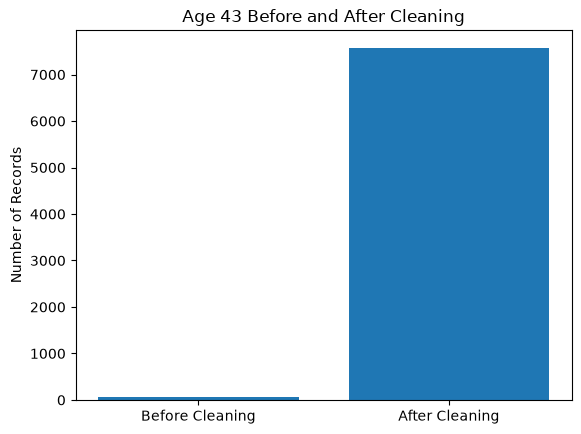

In [18]:
# Create a chart
import matplotlib.pyplot as plt

ages = ["Before Cleaning", "After Cleaning"]
counts = [original_43, cleaned_43]

plt.bar(ages, counts)
plt.title("Age 43 Before and After Cleaning")
plt.ylabel("Number of Records")
plt.show()

In [19]:
# Finding

print("Finding:")
print("The original data had only 55 records with age 43.")
print("After cleaning, 7,573 records have age 43.")
print("This happened because invalid age values were replaced using the median age.")
print("This created a large concentration of records at age 43.")

Finding:
The original data had only 55 records with age 43.
After cleaning, 7,573 records have age 43.
This happened because invalid age values were replaced using the median age.
This created a large concentration of records at age 43.
